In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2022-11-04


'2022-11-04'

In [31]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

taxol = '[Taxol] ' r'$(\mu M)$'#'[SiR] ' r'$(\mu M)$'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [4]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
snsblue = '#225b91'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


## Import Kappa csv ##

In [5]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [6]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i).rfind('SiR') != -1]
folders

[WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH1_DCX1nM_typeWT_SiR10uM'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH2_DCX1nM_typeWT_SiR10uM'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH3_DCX1nM_typeWT_SiR10uM-prewarmed30s'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH4_DCX1nM_typeWT_SiR10uM')]

In [7]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('final') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH1_DCX1nM_typeWT_SiR10uM/2-Stack_Composite-final-color.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH1_DCX1nM_typeWT_SiR10uM/6-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH2_DCX1nM_typeWT_SiR10uM/1-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH2_DCX1nM_typeWT_SiR10uM/2-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH2_DCX1nM_typeWT_SiR10uM/3-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH2_DCX1nM_typeWT_SiR10uM/4-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DCXWT_notax/CH3_DCX1nM_typeWT_SiR10uM-prewarmed30s/1-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-10-17_SiRtubmts_DC

In [8]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [9]:
dates= []
CH= []
tax= []
dcx = []
dcxtype= []
for i in files:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    dcx0 = findmetadata("DCX",'nM',i)
    dcx = dcx + [dcx0] 
    
    type0 = findmetadata("type",'_',i)
    dcxtype = dcxtype + [type0] 
    
    tax0 = findmetadata("SiR",'uM',i)
    tax = tax + [tax0] 
    

print(dates,CH,dcx, dcxtype,tax,len(dates))

['2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17', '2022-10-17'] ['1', '1', '2', '2', '2', '2', '3', '3', '3', '4', '4', '4', '4', '4', '4', '4'] ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1'] ['WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT'] ['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10'] 16


In [10]:
roll = 5
c = 0 
joindata = pd.DataFrame(columns=[] , index=[])
for i in files:
    data0 = pd.read_csv(i, encoding='utf-8')
    
    for j in data0['Curve Name'].unique():
        curvedata = data0[data0['Curve Name'] == j]
        array = curvedata['Green Intensity'].values
        
        curvedata['Date'] = dates[c]
        curvedata['CH'] = CH[c]
        curvedata[DCXconc] = dcx[c]
        curvedata[Type] = dcxtype[c]
        curvedata[taxol] = tax[c]
        curvedata['Filename'] = i.stem
        
        joindata = joindata.append(curvedata, ignore_index=True)
    c += 1
joindata


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Date,CH,[DCX] $(n M)$,DCX Type,[SiR] $(\mu M)$,Filename
0,CURVE 1,40.316328,0.26224,0.465266,3.066224,30.432301,0.003459,1,405.0,53.0,0.0,2022-10-17,1,1,WT,10,2-Stack_Composite-final-color
1,CURVE 1,40.316328,0.26224,0.465266,3.141128,30.439572,0.003536,1,262.0,447.0,0.0,2022-10-17,1,1,WT,10,2-Stack_Composite-final-color
2,CURVE 1,40.316328,0.26224,0.465266,3.215450,30.446766,0.003614,1,142.0,1178.0,0.0,2022-10-17,1,1,WT,10,2-Stack_Composite-final-color
3,CURVE 1,40.316328,0.26224,0.465266,3.289192,30.453884,0.003693,1,142.0,1178.0,0.0,2022-10-17,1,1,WT,10,2-Stack_Composite-final-color
4,CURVE 1,40.316328,0.26224,0.465266,3.362360,30.460926,0.003775,1,75.0,1603.0,0.0,2022-10-17,1,1,WT,10,2-Stack_Composite-final-color
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,CURVE 9,17.582068,0.01134,0.004413,26.197326,9.235928,0.007262,1,9.0,31.0,157.0,2022-10-17,4,1,WT,10,7-Stack_Composite-final
52604,CURVE 9,17.582068,0.01134,0.004413,26.285226,9.215516,0.007209,1,5.0,13.0,176.0,2022-10-17,4,1,WT,10,7-Stack_Composite-final
52605,CURVE 9,17.582068,0.01134,0.004413,26.373534,9.194949,0.007157,1,32.0,159.0,176.0,2022-10-17,4,1,WT,10,7-Stack_Composite-final
52606,CURVE 9,17.582068,0.01134,0.004413,26.462252,9.174225,0.007104,1,32.0,145.0,211.0,2022-10-17,4,1,WT,10,7-Stack_Composite-final


In [11]:
newdirectory = str(path.parents[1])+'//Curvature_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [12]:
name = dates[0]+ '_SiR_jointdata-on_'+date_today +'.csv'
name

'2022-10-17_SiR_jointdata-on_2022-11-03.csv'

In [13]:
joindata.to_csv(path/(name), encoding='utf-8', index=False)
joindata.to_csv(newmydir/(name), encoding='utf-8', index=False)

## Join various data sheets ##

In [67]:
#askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = newmydir

In [68]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if str(i).rfind('csv') != -1 if str(i).rfind(date_today) != -1 if str(i).rfind('jointdata') != -1]

files

[WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Curvature_Data_Sheets/2022-02-28_jointdata-on_2022-05-31.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Curvature_Data_Sheets/2022-03-01_jointdata-on_2022-05-31.csv')]

In [69]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('jointdata-on_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Normal Intensity,Date,CH,[DCX] $(n M)$,Filename
0,CURVE 1,21.492819,0.037069,0.027364,33.572043,15.898432,0.010862,-1,0.0,33.0,33.0,0.000000,2022-02-28,1,1.0,1_Composite_final
1,CURVE 1,21.492819,0.037069,0.027364,33.634781,15.945080,0.011113,-1,0.0,110.0,110.0,0.000000,2022-02-28,1,1.0,1_Composite_final
2,CURVE 1,21.492819,0.037069,0.027364,33.696895,15.991347,0.011371,-1,0.0,110.0,110.0,0.000000,2022-02-28,1,1.0,1_Composite_final
3,CURVE 1,21.492819,0.037069,0.027364,33.758388,16.037235,0.011634,-1,0.0,109.0,109.0,0.000000,2022-02-28,1,1.0,1_Composite_final
4,CURVE 1,21.492819,0.037069,0.027364,33.819264,16.082747,0.011904,-1,7.0,145.0,145.0,0.006692,2022-02-28,1,1.0,1_Composite_final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64763,CURVE 15,8.748654,0.026783,0.017434,45.405851,6.350519,0.061319,1,89.0,57.0,57.0,0.445000,2022-03-01,1,1.0,9_Composite-final
64764,CURVE 15,8.748654,0.026783,0.017434,45.467943,6.333301,0.062194,1,89.0,57.0,57.0,0.445000,2022-03-01,1,1.0,9_Composite-final
64765,CURVE 15,8.748654,0.026783,0.017434,45.529964,6.315835,0.063060,1,81.0,65.0,65.0,0.405000,2022-03-01,1,1.0,9_Composite-final
64766,CURVE 15,8.748654,0.026783,0.017434,45.591914,6.298116,0.063918,1,70.0,75.0,75.0,0.350000,2022-03-01,1,1.0,9_Composite-final


### If data already joint ###

In [42]:
askfile = filedialog.askopenfilename()
joindata = pd.read_csv(askfile, encoding='utf-8')

In [43]:
path = Path(askfile).parents[0]
path

WindowsPath('C:/Users/sofia/OneDrive/Documentos/mcgill/brouhardlab/data/fall2022/TaxolMts')

## One Curve ##

In [44]:
keep_columns = ['Date','CH', 'Filename','Curve Name','Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity',DCXconc,Type,taxol]
unique_curve_columns = ['Date','CH', 'Filename','Curve Name']

analze_data = joindata[keep_columns]
data_unique = analze_data[unique_curve_columns].drop_duplicates(subset =unique_curve_columns, keep = 'first')
data_unique


,Date,CH,Filename,Curve Name
0,2022-02-28,1,1_Composite_final,CURVE 1
640,2022-02-28,1,1_Composite_final,CURVE 2
1536,2022-02-28,1,1_Composite_final,CURVE 3
1664,2022-02-28,1,1_Composite_final,CURVE 4
1920,2022-02-28,1,1_Composite_final,CURVE 5
...,...,...,...,...
64128,2022-03-01,1,9_Composite-final,CURVE 11
64256,2022-03-01,1,9_Composite-final,CURVE 12
64384,2022-03-01,1,9_Composite-final,CURVE 13
64512,2022-03-01,1,9_Composite-final,CURVE 14


In [45]:
def single_curve(data,i):
    singlecurve = data.loc[(data['Date'] == data_unique['Date'].values[i]) & 
                 (data['CH'] == data_unique['CH'].values[i]) &
                 (data['Filename'] == data_unique['Filename'].values[i]) &
                 (data['Curve Name'] == data_unique['Curve Name'].values[i])
                ] 
    return singlecurve

In [46]:
singlecurve = single_curve(analze_data,50)
singlecurve

,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,[Taxol] $(\mu M)$
14208,2022-02-28,1,4_Composite_final,CURVE 1,0.010382,4.0,66.0,66.0,1.0,WT,10
14209,2022-02-28,1,4_Composite_final,CURVE 1,0.010830,4.0,66.0,66.0,1.0,WT,10
14210,2022-02-28,1,4_Composite_final,CURVE 1,0.011300,0.0,76.0,76.0,1.0,WT,10
14211,2022-02-28,1,4_Composite_final,CURVE 1,0.011793,0.0,63.0,63.0,1.0,WT,10
14212,2022-02-28,1,4_Composite_final,CURVE 1,0.012310,0.0,63.0,63.0,1.0,WT,10
...,...,...,...,...,...,...,...,...,...,...,...
14587,2022-02-28,1,4_Composite_final,CURVE 1,0.473488,47.0,206.0,206.0,1.0,WT,10
14588,2022-02-28,1,4_Composite_final,CURVE 1,0.460829,47.0,206.0,206.0,1.0,WT,10
14589,2022-02-28,1,4_Composite_final,CURVE 1,0.448411,91.0,136.0,136.0,1.0,WT,10
14590,2022-02-28,1,4_Composite_final,CURVE 1,0.436240,91.0,136.0,136.0,1.0,WT,10


In [47]:
def normal_rolling_avg(singlecurve,roll,channels):
    for channel in channels:
        if channel == 'Point Curvature (um-1)':
            singlecurve[channel+' Rolling'] =  singlecurve[channel].rolling(roll, min_periods=1, center=True).mean()
            singlecurve[channel+' Rolling std'] =  singlecurve[channel].rolling(roll, min_periods=1, center=True).std()
        else:   
            max_channel = singlecurve[channel].max()
            min_channel = singlecurve[channel].min()

            singlecurve[channel+' Normalized'] =  (singlecurve[channel] - min_channel) / (max_channel -  min_channel)

            singlecurve[channel+' Rolling'] =  singlecurve[channel+' Normalized'].rolling(roll, min_periods=1, center=True).mean()
            singlecurve[channel+' Rolling std'] =  singlecurve[channel+' Normalized'].rolling(roll, min_periods=1, center=True).std()

    return singlecurve


In [48]:
roll = 50
channels = ['Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity']

data = normal_rolling_avg(singlecurve,roll,channels)
data

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,...,Point Curvature (um-1) Rolling std,Red Intensity Normalized,Red Intensity Rolling,Red Intensity Rolling std,Green Intensity Normalized,Green Intensity Rolling,Green Intensity Rolling std,Blue Intensity Normalized,Blue Intensity Rolling,Blue Intensity Rolling std
14208,2022-02-28,1,4_Composite_final,CURVE 1,0.010382,4.0,66.0,66.0,1.0,WT,...,0.006111,0.007692,0.007154,0.014860,0.079498,0.124184,0.105386,0.079498,0.124184,0.105386
14209,2022-02-28,1,4_Composite_final,CURVE 1,0.010830,4.0,66.0,66.0,1.0,WT,...,0.006544,0.007692,0.008876,0.017002,0.079498,0.123753,0.103280,0.079498,0.123753,0.103280
14210,2022-02-28,1,4_Composite_final,CURVE 1,0.011300,0.0,76.0,76.0,1.0,WT,...,0.007000,0.000000,0.008547,0.016759,0.121339,0.123353,0.101295,0.121339,0.123353,0.101295
14211,2022-02-28,1,4_Composite_final,CURVE 1,0.011793,0.0,63.0,63.0,1.0,WT,...,0.007479,0.000000,0.008242,0.016525,0.066946,0.122983,0.099421,0.066946,0.122983,0.099421
14212,2022-02-28,1,4_Composite_final,CURVE 1,0.012310,0.0,63.0,63.0,1.0,WT,...,0.007984,0.000000,0.007958,0.016299,0.066946,0.122637,0.097647,0.066946,0.122637,0.097647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14587,2022-02-28,1,4_Composite_final,CURVE 1,0.473488,47.0,206.0,206.0,1.0,WT,...,0.123825,0.090385,0.121667,0.084443,0.665272,0.745328,0.177699,0.665272,0.745328,0.177699
14588,2022-02-28,1,4_Composite_final,CURVE 1,0.460829,47.0,206.0,206.0,1.0,WT,...,0.119811,0.090385,0.113196,0.071806,0.665272,0.746934,0.180623,0.665272,0.746934,0.180623
14589,2022-02-28,1,4_Composite_final,CURVE 1,0.448411,91.0,136.0,136.0,1.0,WT,...,0.115726,0.175000,0.104121,0.053573,0.372385,0.748655,0.183695,0.372385,0.748655,0.183695
14590,2022-02-28,1,4_Composite_final,CURVE 1,0.436240,91.0,136.0,136.0,1.0,WT,...,0.111578,0.175000,0.100855,0.051674,0.372385,0.750349,0.186971,0.372385,0.750349,0.186971


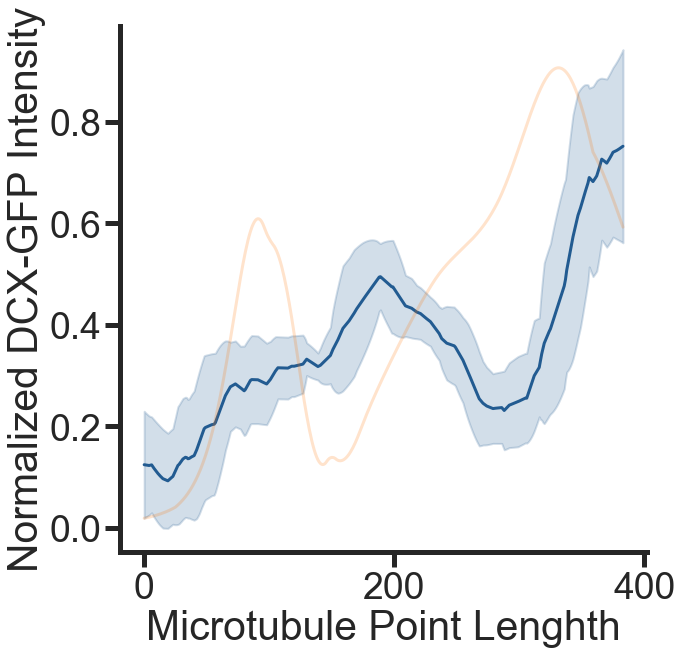

In [49]:
#data = data.sort_values(by=['Point Curvature (um-1)'])

fig, ax = plt.subplots(1,1,figsize=(10.5,10))

#x = data['Point Curvature (um-1)'].values
x = range(0,len(data['Green Intensity'].values))
y = data['Point Curvature (um-1) Rolling'].values
mean = data['Green Intensity Rolling'].values
std = data['Green Intensity Rolling std'].values

plt.plot(x, mean, color=snsblue)
plt.plot(x, y, color=orange, alpha=0.2)
plt.fill_between(x, mean - std, mean + std, color=snsblue, alpha=0.2)

ax.set_ylabel('Normalized DCX-GFP Intensity')
ax.set_xlabel('Microtubule Point Lenghth')
#ax.set_xlim(0,1.5)
#ax.set_ylim(0,0.8)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_dcx_'+date_today+'.svg'))

## Normalize by FOV ##

In [50]:
keep_columns = ['Date','CH', 'Filename','Curve Name','Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity',DCXconc,Type,taxol]
unique_curve_columns = ['Date','CH', 'Filename']

analze_data = joindata[keep_columns]
data_unique = analze_data[unique_curve_columns].drop_duplicates(subset =unique_curve_columns, keep = 'first')
data_unique

,Date,CH,Filename
0,2022-02-28,1,1_Composite_final
5120,2022-02-28,1,2_Composite_final
9088,2022-02-28,1,3_Composite_final
14208,2022-02-28,1,4_Composite_final
16512,2022-02-28,1,5_Composite_final
19712,2022-02-28,1,6_Composite_final
24960,2022-03-01,1,3_Composite-final
32000,2022-03-01,1,4_Composite-final
40192,2022-03-01,1,5_Composite-final
44544,2022-03-01,1,6_Composite-final


In [51]:
def single_FOV(data,i):
    singleFOV = data.loc[(data['Date'] == data_unique['Date'].values[i]) & 
                 (data['CH'] == data_unique['CH'].values[i]) &
                 (data['Filename'] == data_unique['Filename'].values[i]) 
                        ] 
    return singleFOV

In [52]:
def normalizeFOV(singleFOV,channels):
    for channel in channels:
            max_channel = singleFOV[channel].max()
            min_channel = singleFOV[channel].min()

            singleFOV[channel+' Normalized'] =  (singleFOV[channel] - min_channel) / (max_channel -  min_channel)

    return singleFOV


In [53]:
channels = ['Red Intensity','Green Intensity','Blue Intensity']

results = pd.DataFrame(columns=[] , index=[])
for i in range(0,len(data_unique)):
    
    singleFOV = single_FOV(analze_data,i)
    results0 = normalizeFOV(singleFOV,channels)
    results = pd.concat([results, results0], sort=False)
    
results

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,[Taxol] $(\mu M)$,Red Intensity Normalized,Green Intensity Normalized,Blue Intensity Normalized
0,2022-02-28,1,1_Composite_final,CURVE 1,0.010862,0.0,33.0,33.0,1.0,WT,10,0.000000,0.086162,0.086162
1,2022-02-28,1,1_Composite_final,CURVE 1,0.011113,0.0,110.0,110.0,1.0,WT,10,0.000000,0.287206,0.287206
2,2022-02-28,1,1_Composite_final,CURVE 1,0.011371,0.0,110.0,110.0,1.0,WT,10,0.000000,0.287206,0.287206
3,2022-02-28,1,1_Composite_final,CURVE 1,0.011634,0.0,109.0,109.0,1.0,WT,10,0.000000,0.284595,0.284595
4,2022-02-28,1,1_Composite_final,CURVE 1,0.011904,7.0,145.0,145.0,1.0,WT,10,0.006130,0.378590,0.378590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64763,2022-03-01,1,9_Composite-final,CURVE 15,0.061319,89.0,57.0,57.0,1.0,WT,10,0.082560,0.195804,0.195804
64764,2022-03-01,1,9_Composite-final,CURVE 15,0.062194,89.0,57.0,57.0,1.0,WT,10,0.082560,0.195804,0.195804
64765,2022-03-01,1,9_Composite-final,CURVE 15,0.063060,81.0,65.0,65.0,1.0,WT,10,0.075139,0.223776,0.223776
64766,2022-03-01,1,9_Composite-final,CURVE 15,0.063918,70.0,75.0,75.0,1.0,WT,10,0.064935,0.258741,0.258741


## Bin data and Plot ##

In [54]:
data = results.sort_values(by=['Point Curvature (um-1)'])
binsize = 0.05
limX= 1.5
data_interval_mean = data.groupby(pd.cut(data['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).mean()
data_interval_std = data.groupby(pd.cut(data['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).std()

In [55]:
data_interval_mean['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2
data_interval_std['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2

In [61]:
DataLabel = [['DCX-GFP'],['Tubulin'],['Tubulin']]
channels=['Red','Green','Blue']
colors=[green,magenta,blue]

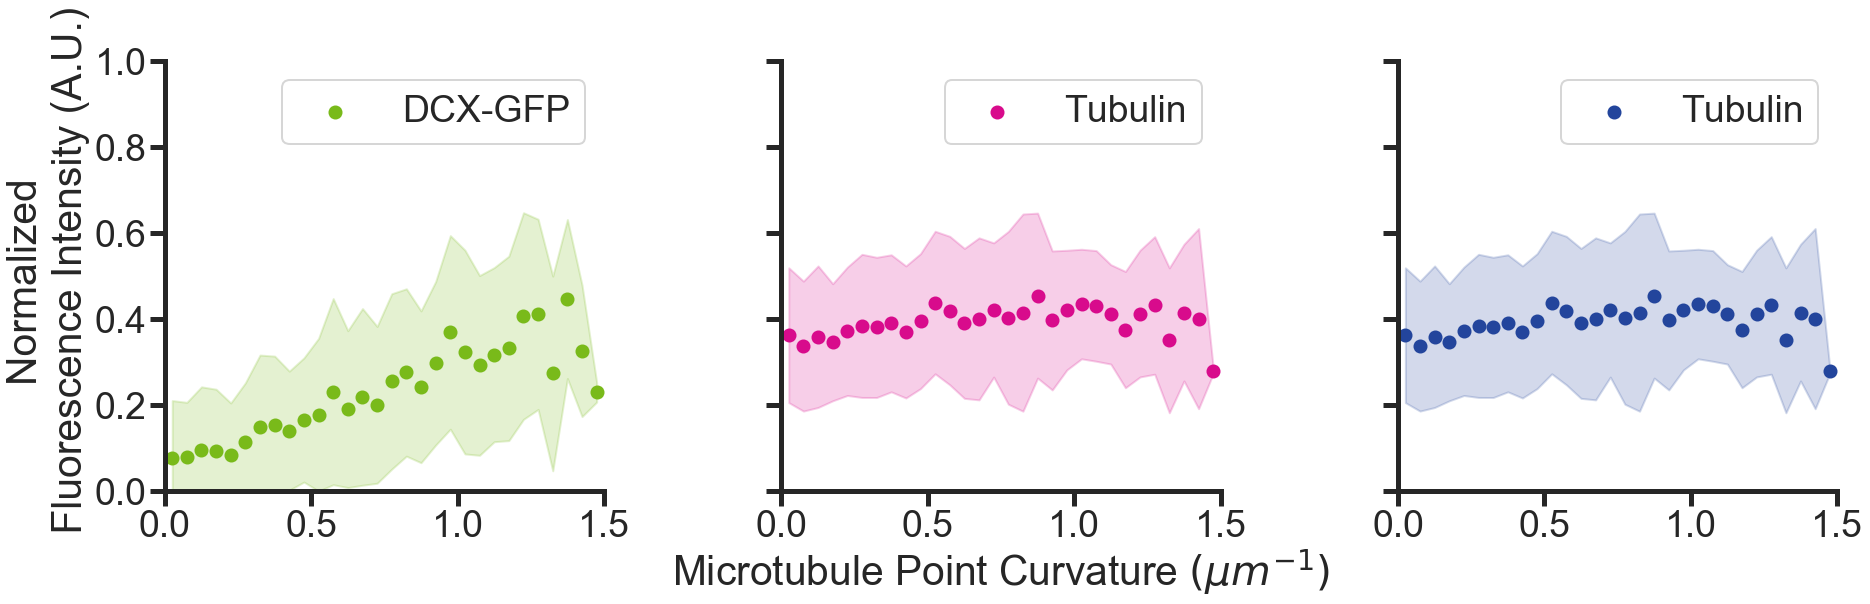

In [62]:
gs = fig.add_gridspec(1, 3, hspace=0, wspace=0)
fig, ax = plt.subplots(1,3,figsize=(27,9), sharey=True)

count = 0
for i in np.arange(len(ax)):
            
    x = data_interval_mean['Bin Center'].values
    channel = channels[count]
    mean = data_interval_mean[channel+' Intensity Normalized'].values
    std = data_interval_std[channel+' Intensity Normalized'].values
    color = colors[count]
    ax[i].scatter(x, mean, color=color)
    ax[i].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
    ax[i].set_ylim(0,1)
    ax[i].set_xlim(0,1.5)
    
    ax[i].spines['left'].set_lw(5)
    ax[i].spines['bottom'].set_lw(5)
    ax[i].tick_params(axis='both', width = 5, length = 15)
    
    ax[i].legend(DataLabel[i],loc='upper right')

    count += 1


ax[0].set_ylabel('Normalized \n Fluorescence Intensity (A.U.)')
ax[1].set_xlabel('Microtubule Point Curvature '  r'$(\mu m ^{-1})$')

#fig.supxlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')

sns.set_style("ticks")
sns.despine()

sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_dcx_'+date_today+'.svg'))

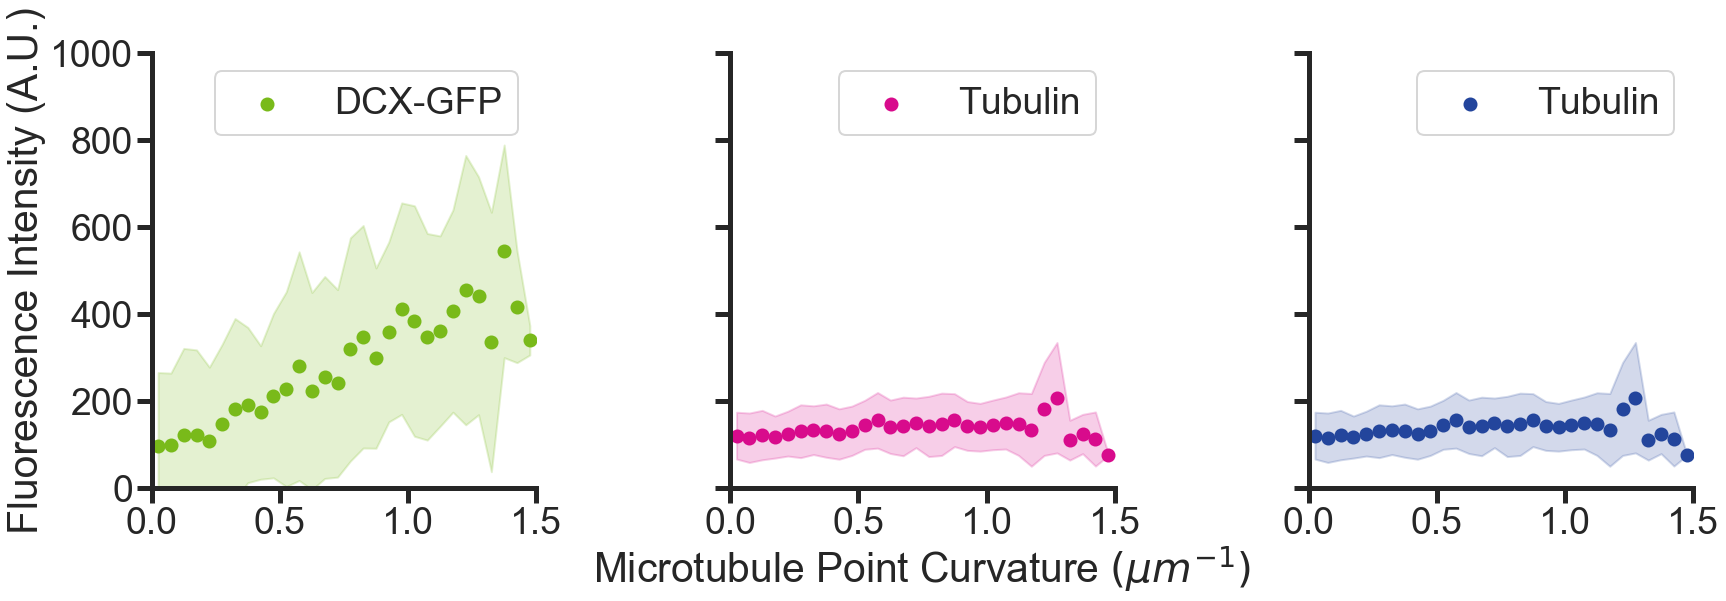

In [63]:
gs = fig.add_gridspec(1, 3, hspace=0, wspace=0)
fig, ax = plt.subplots(1,3,figsize=(25,9), sharey=True)

count = 0
for i in np.arange(len(ax)):
            
    x = data_interval_mean['Bin Center'].values
    channel = channels[count]
    mean = data_interval_mean[channel+' Intensity'].values
    std = data_interval_std[channel+' Intensity'].values
    color = colors[count]
    ax[i].scatter(x, mean, color=color)
    ax[i].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
    ax[i].set_ylim(0,1000)
    ax[i].set_xlim(0,1.5)
    
    ax[i].spines['left'].set_lw(5)
    ax[i].spines['bottom'].set_lw(5)
    ax[i].tick_params(axis='both', width = 5, length = 15)
    
    ax[i].legend(DataLabel[i],loc='upper right')

    count += 1


ax[0].set_ylabel('Fluorescence Intensity (A.U.)')
ax[1].set_xlabel('Microtubule Point Curvature '  r'$(\mu m ^{-1})$')

#fig.supxlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')

sns.set_style("ticks")
sns.despine()

sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_dcx_'+date_today+'.svg'))

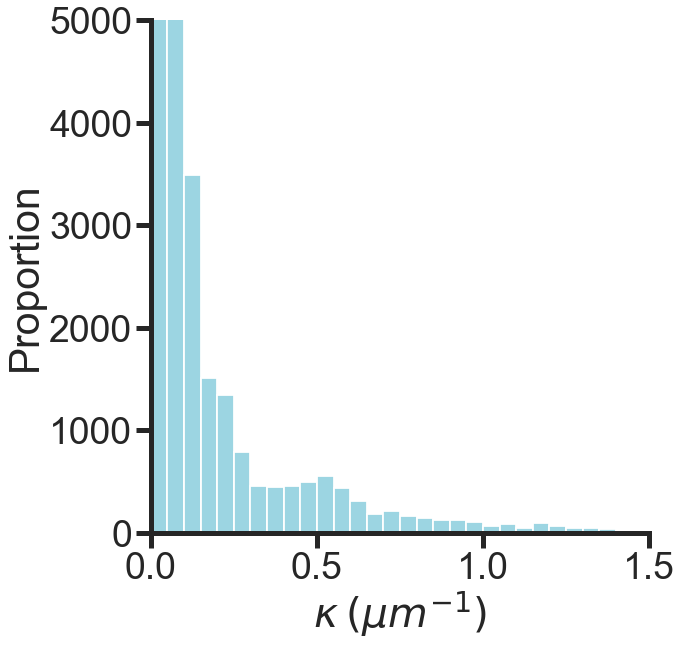

In [27]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))
sns.histplot(data, x='Point Curvature (um-1)',bins=np.arange(0, limX+binsize, binsize), color='#7BC8D9')#, stat='probability')
#n, bins, patches = plt.hist(x, 50, density = True, facecolor='#7BC8D9')

ax.set_ylabel('Proportion')
ax.set_xlabel( r'$\kappa \: (\mu m ^{-1})$')
ax.set_xlim(0,1.5)
ax.set_ylim(0,5000)
#plt.yticks([0,0.15,0.3])

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('histogram_curves'+date_today+'.svg'))